# Caso DT-009 — Concentracion de la renta pesquera
## 🟢 Nivel NOVATO — Ver la concentracion con un grafico y dos indices simples.

**Curso:** IA Aplicada a la Produccion Pesquera · UTN FRCh · PesquerosEnIA · 2026
**Autor:** Ariel Giamportone — Ingeniero Pesquero, Cientifico de datos e IA, docente-investigador UTN FRTDF, fundador Pesqueros en IA
**Apoya a:** DT-ALGP-2026-009 (dependencia tecnologica naval y concentracion de renta en merluza negra) y DT-ALGP-2026-012 (captura silenciosa de la renta pesquera)

---

> **Frase ancla:** *La concentracion no se declama; se calcula. Un solo indice vuelve visible lo que el discurso mantiene difuso.*

**Que hace este caso.** La CITC (Cuota Individual Transferible de Captura) es un instrumento; su *aplicacion* puede concentrar la renta en pocas manos sin que eso sea evidente a simple vista. Aca convertimos esa afirmacion de economia politica en algo medible y reproducible: tomamos las participaciones en la CMP de merluza negra y calculamos indices de concentracion estandar.

**Declaracion de conflicto de interes.** La UTN FRTDF es beneficiaria *prima facie* de la Ley provincial 1545/2024 y de la Ley 1614/2026. Este material se produce en el marco docente-investigador del autor y no constituye asesoramiento a ninguna de las empresas mencionadas.


### Taxonomia de evidencia (invariante de la serie DT-ALGP)

Todo valor que usamos lleva una etiqueta. **Nunca llenamos un hueco con un numero inventado.**

| Clase | Significado |
|---|---|
| `CONFIRMADO` | Verificado en fuente oficial primaria |
| `ESTIMADO` | Calculado a partir de supuestos declarados |
| `REFERENCIAL` | Tomado de fuente secundaria, sujeto a revision |
| `HUECO` | Dato faltante, se marca y no se completa |

> Las participaciones nominales de las tres empresas son **REFERENCIAL**. El reparto de la cola (operadores menores) es **ESTIMADO / ilustrativo**: sirve para el ejercicio distributivo, **no** es una afirmacion sobre firmas concretas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paleta institucional de la serie DT-ALGP
AZUL, ROJO, VERDE, NARANJA = '#08519c', '#a50f15', '#005a32', '#cc6600'
plt.rcParams.update({'figure.figsize': (10, 5.5), 'font.size': 11})
np.random.seed(42)
print('✓ Librerias cargadas')

✓ Librerias cargadas


In [2]:
# ── Participaciones en la CMP de merluza negra ────────────────────────────────
# Las tres primeras son REFERENCIAL (DT-009). La cola es ESTIMADO / ilustrativo.
titulares = pd.DataFrame({
    'operador':   ['Estremar', 'Argenova', 'Pesantar',
                   'Operador D', 'Operador E', 'Operador F',
                   'Operador G', 'Operador H', 'Operador I'],
    'share_pct':  [37.83, 23.02, 19.94,       # REFERENCIAL
                   6.40, 4.60, 3.30, 2.20, 1.60, 1.11],  # ESTIMADO (suman 19.21)
    'evidencia':  ['REFERENCIAL', 'REFERENCIAL', 'REFERENCIAL',
                   'ESTIMADO', 'ESTIMADO', 'ESTIMADO',
                   'ESTIMADO', 'ESTIMADO', 'ESTIMADO'],
})
# Coherencia: las participaciones deben sumar 100 %
assert abs(titulares['share_pct'].sum() - 100.0) < 1e-9, 'Las participaciones no suman 100 %'
titulares['share'] = titulares['share_pct'] / 100.0
print('Titulares:', len(titulares), '| Suma =', round(titulares['share_pct'].sum(), 2), '%')
titulares

Titulares: 9 | Suma = 100.0 %


,operador,share_pct,evidencia,share
0,Estremar,37.83,REFERENCIAL,0.3783
1,Argenova,23.02,REFERENCIAL,0.2302
2,Pesantar,19.94,REFERENCIAL,0.1994
3,Operador D,6.40,ESTIMADO,0.0640
4,Operador E,4.60,ESTIMADO,0.0460
5,Operador F,3.30,ESTIMADO,0.0330
6,Operador G,2.20,ESTIMADO,0.0220
7,Operador H,1.60,ESTIMADO,0.0160
8,Operador I,1.11,ESTIMADO,0.0111


In [3]:
# ── Funciones de concentracion (reutilizables) ────────────────────────────────
def concentration_ratio(shares, k):
    '''CRk: suma de las k mayores participaciones (en %).'''
    return np.sort(shares)[::-1][:k].sum() * 100

def hhi(shares):
    '''Herfindahl-Hirschman Index sobre participaciones en % (0–10000).'''
    return float(np.sum((np.asarray(shares) * 100) ** 2))

def lorenz(shares):
    '''Devuelve (x, y) de la curva de Lorenz a partir de participaciones.'''
    s = np.sort(np.asarray(shares))
    cum = np.cumsum(s) / s.sum()
    x = np.linspace(0, 1, len(s) + 1)
    y = np.concatenate([[0], cum])
    return x, y

def gini(shares):
    '''Coeficiente de Gini (0 = igualdad total, 1 = concentracion total).'''
    s = np.sort(np.asarray(shares, dtype=float))
    n = len(s)
    idx = np.arange(1, n + 1)
    return float((np.sum((2 * idx - n - 1) * s)) / (n * s.sum()))

print('✓ Funciones listas')

✓ Funciones listas


In [4]:
sh = titulares['share'].values

cr1 = concentration_ratio(sh, 1)
cr3 = concentration_ratio(sh, 3)
cr4 = concentration_ratio(sh, 4)
indice_hhi = hhi(sh)
indice_gini = gini(sh)

print(f'CR1 (lider)          : {cr1:5.2f} %')
print(f'CR3 (top 3)          : {cr3:5.2f} %   <- agregado CITC ~80.80 % (REFERENCIAL)')
print(f'CR4 (top 4)          : {cr4:5.2f} %')
print(f'HHI                  : {indice_hhi:6.0f}')
print(f'Gini                 : {indice_gini:5.3f}')

def banda(v, cortes):
    etiquetas = ['no concentrado', 'moderada', 'alta']
    return etiquetas[sum(v >= c for c in cortes)]

print()
print(f'HHI segun guia 2010 (1500 / 2500): {banda(indice_hhi, [1500, 2500])}')
print(f'HHI segun guia 2023 (1000 / 1800): {banda(indice_hhi, [1000, 1800])}')
print(f'CR3 = {cr3:.1f} %  y  Gini = {indice_gini:.2f}  -> senal de concentracion marcada, con independencia del umbral HHI')

CR1 (lider)          : 37.83 %
CR3 (top 3)          : 80.79 %   <- agregado CITC ~80.80 % (REFERENCIAL)
CR4 (top 4)          : 87.19 %
HHI                  :   2440
Gini                 : 0.555

HHI segun guia 2010 (1500 / 2500): moderada
HHI segun guia 2023 (1000 / 1800): alta
CR3 = 80.8 %  y  Gini = 0.55  -> senal de concentracion marcada, con independencia del umbral HHI


**Lectura rapida.** El numero mas intuitivo es el **CR3**: la suma de las tres participaciones mas grandes. Si tres operadores concentran ~81 % de la cuota, la renta esta concentrada, punto. El **HHI** afina esa lectura: aca queda cerca del limite entre "moderada" y "alta" segun la guia que uses (mira los dos renglones de arriba). El **Gini** (0 = todos iguales, 1 = uno se queda con todo) confirma la señal.

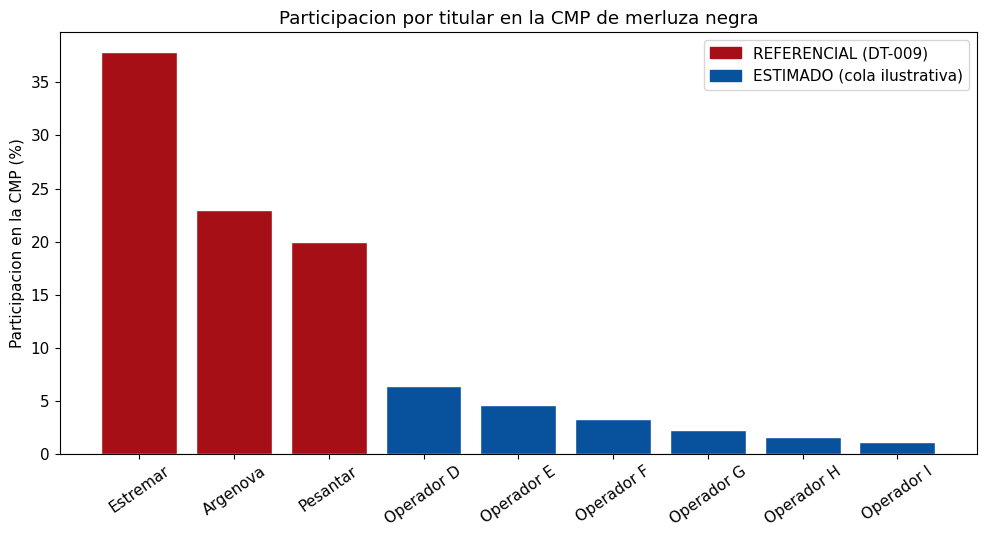

In [5]:
fig, ax = plt.subplots()
colores = [ROJO if e == 'REFERENCIAL' else AZUL for e in titulares['evidencia']]
ax.bar(titulares['operador'], titulares['share_pct'], color=colores, edgecolor='white')
ax.axhline(0, color='0.3', lw=0.8)
ax.set_ylabel('Participacion en la CMP (%)')
ax.set_title('Participacion por titular en la CMP de merluza negra')
ax.tick_params(axis='x', rotation=35)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=ROJO, label='REFERENCIAL (DT-009)'),
                   Patch(color=AZUL, label='ESTIMADO (cola ilustrativa)')])
plt.tight_layout(); plt.show()

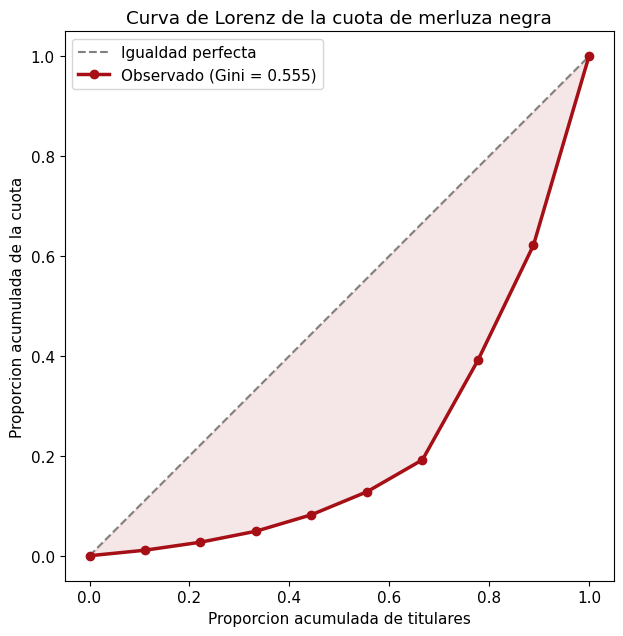

In [6]:
x, y = lorenz(titulares['share'].values)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot([0, 1], [0, 1], '--', color='0.5', label='Igualdad perfecta')
ax.plot(x, y, color=ROJO, lw=2.5, marker='o', label=f'Observado (Gini = {gini(titulares.share.values):.3f})')
ax.fill_between(x, y, x, color=ROJO, alpha=0.10)
ax.set_xlabel('Proporcion acumulada de titulares')
ax.set_ylabel('Proporcion acumulada de la cuota')
ax.set_title('Curva de Lorenz de la cuota de merluza negra')
ax.legend(); ax.set_aspect('equal'); plt.tight_layout(); plt.show()

---
## Sintesis

En una sola figura (Lorenz) y dos numeros (HHI, Gini) mostramos lo que un parrafo puede diluir: la renta de la merluza negra esta fuertemente concentrada. Ese es, en clave de datos, el corazon de la **captura silenciosa de la renta pesquera** (DT-012). El instrumento (CITC) no es el problema; su aplicacion concentradora, medida y trazable, si es discutible como politica publica.

**Transferible.** Los mismos indices (CR, HHI, Gini, Lorenz) sirven para cualquier cuota, permiso o subsidio del sector. La tecnica es general; el dato manda.

---
### Que NO afirma este notebook

1. No afirma las participaciones exactas de cada empresa: son **REFERENCIAL** y deben confirmarse en el acto administrativo del CFP antes de cualquier publicacion.
2. No afirma que la concentracion sea ilegal: la CITC es un instrumento legitimo. Lo que se mide es el *grado* de concentracion resultante de su aplicacion.
3. No afirma causalidad politica: cuantifica un estado de situacion, no prueba intencion.
4. No afirma nada sobre la sostenibilidad biologica del stock (ese eje se trata en DT-007).

**Fuente para cerrar el HUECO:** acto de asignacion de CITC de merluza negra publicado por el CFP.